# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how market sentiment (Fear/Greed) affects trader performance and behavior.

## Datasets Used
1. Bitcoin Market Sentiment Dataset  
2. Historical Trader Data (Hyperliquid)

# Part A: Data Preparation

In [3]:
import pandas as pd

# Load datasets
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

# Preview data
print("Sentiment Data:")
print(sentiment.head())

print("\nTrades Data:")
print(trades.head())

Sentiment Data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1

## Dataset Overview

In [5]:
# Shape (rows, columns)
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


## Data Cleaning

In [7]:
# Missing values
print("Missing values (Sentiment):")
print(sentiment.isnull().sum())

print("\nMissing values (Trades):")
print(trades.isnull().sum())

# Duplicates
print("\nDuplicate rows (Sentiment):", sentiment.duplicated().sum())
print("Duplicate rows (Trades):", trades.duplicated().sum())

Missing values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows (Sentiment): 0
Duplicate rows (Trades): 0


## Date Conversion & Alignment

In [9]:
# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trades timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Create date column (daily level)
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

# Check
print(trades[['Timestamp IST', 'date']].head())

        Timestamp IST       date
0 2024-12-02 22:50:00 2024-12-02
1 2024-12-02 22:50:00 2024-12-02
2 2024-12-02 22:50:00 2024-12-02
3 2024-12-02 22:50:00 2024-12-02
4 2024-12-02 22:50:00 2024-12-02


## Data Merging

In [11]:
# Merge datasets on date
merged = pd.merge(trades, sentiment, on='date', how='inner')

# Check result
print("Merged shape:", merged.shape)

print("\nSample data:")
print(merged[['date', 'classification', 'Closed PnL']].head())

Merged shape: (211218, 20)

Sample data:
        date classification  Closed PnL
0 2024-12-02  Extreme Greed         0.0
1 2024-12-02  Extreme Greed         0.0
2 2024-12-02  Extreme Greed         0.0
3 2024-12-02  Extreme Greed         0.0
4 2024-12-02  Extreme Greed         0.0


## Feature Engineering

In [13]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)

print(daily_pnl.head())

                                      Account       date  daily_pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11        0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17        0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18        0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22   -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26     1603.1


In [15]:
merged['is_win'] = merged['Closed PnL'].apply(
    lambda x: 1 if x > 0 else (0 if x < 0 else None)
)

win_rate = merged.groupby('Account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'win_rate'}, inplace=True)
print(win_rate.head())

                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.792725
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.773644
2  0x271b280974205ca63b716753467d5a371de622ab  0.715619
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.862079
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.817476


In [18]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)

print(avg_trade_size.head())

                                      Account  avg_trade_size
0  0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab     8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782


In [20]:
trades_per_day = merged.groupby('date').size().reset_index(name='trades_count')

print(trades_per_day.head())


        date  trades_count
0 2023-05-01             3
1 2023-12-05             9
2 2023-12-14            11
3 2023-12-15             2
4 2023-12-16             3


In [22]:
long_short = merged.groupby(['date', 'Side']).size().unstack(fill_value=0)

long_short['long_short_ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

print(long_short.head())

Side        BUY  SELL  long_short_ratio
date                                   
2023-05-01    3     0               inf
2023-12-05    7     2          3.500000
2023-12-14    5     6          0.833333
2023-12-15    2     0               inf
2023-12-16    3     0               inf


# Part B: Analysis

In [24]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()

print(pnl_by_sentiment)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


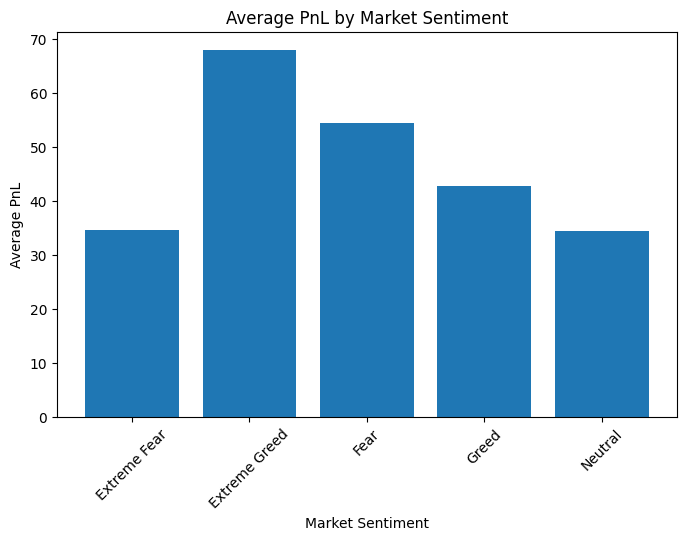

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['Closed PnL'])

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.xticks(rotation=45)

plt.show()

In [28]:
win_rate_sentiment = merged.groupby('classification')['is_win'].mean().reset_index()

print(win_rate_sentiment)

  classification    is_win
0   Extreme Fear  0.762156
1  Extreme Greed  0.891670
2           Fear  0.872886
3          Greed  0.768907
4        Neutral  0.823889


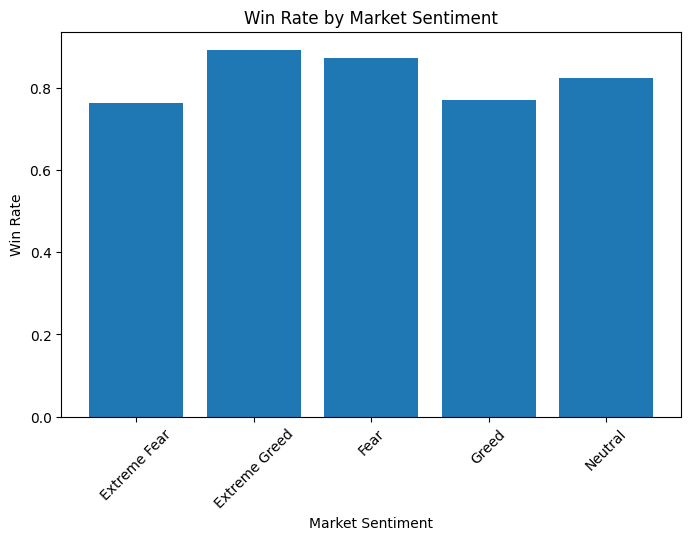

In [51]:
plt.figure(figsize=(8,5))

plt.bar(win_rate_sentiment['classification'], win_rate_sentiment['is_win'])

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.xticks(rotation=45)

plt.show()

In [32]:
trades_sentiment = merged.groupby('classification').size().reset_index(name='trade_count')

print(trades_sentiment)

  classification  trade_count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50303
4        Neutral        37686


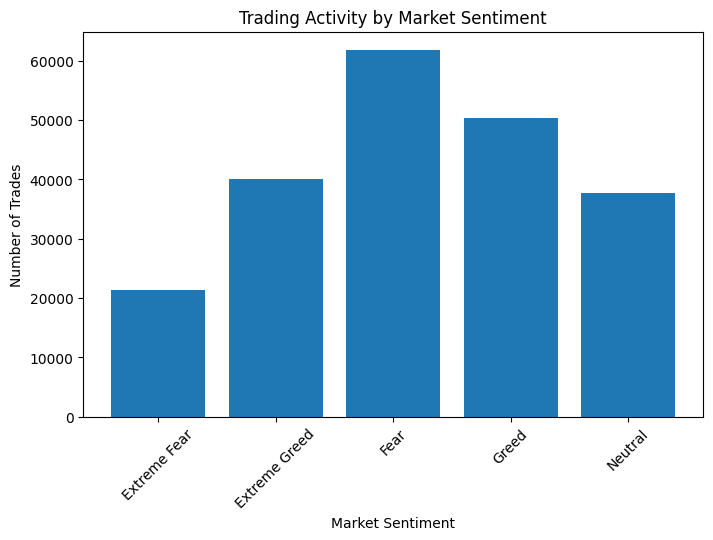

In [52]:
plt.figure(figsize=(8,5))

plt.bar(trades_sentiment['classification'], trades_sentiment['trade_count'])

plt.title("Trading Activity by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

# Key Insights & Observations

Insight 1: Performance vs Sentiment

Traders achieve the highest average PnL and win rates during Extreme Greed conditions. This indicates that traders benefit from strong upward trends, where market direction is clearer and momentum-driven strategies perform better.




Insight 2: Fear vs Greed Behavior

Trading activity is highest during Fear periods, indicating that traders are more active when the market is uncertain or falling. However, despite higher activity, performance (PnL) is lower than during Extreme Greed, suggesting overtrading or panic-driven decisions.

Insight 3: Emotional Extremes Matter

Both Extreme Fear and Extreme Greed show distinct behavior patterns. While Extreme Greed leads to high profitability, Extreme Fear results in lower performance, indicating that trader psychology plays a critical role in outcomes.


Insight 4: Impact of Zero-PnL Trades on Win Rate

Win rates appear artificially high due to the presence of many zero-PnL trades. After excluding these, the analysis focuses only on realized outcomes, providing a more accurate picture of trader performance.

# Strategy Recommendations

Strategy 1:

During Extreme Greed, traders can increase position size or participation, as both win rate and profitability are higher.


Strategy 2:

During Fear periods, traders should reduce trade frequency and avoid overtrading, as high activity does not translate into higher profits.


*These strategies highlight how traders can adapt behavior based on sentiment to optimize risk and returns.*

# **Bonus: Predictive Modeling**

## Objective
To predict whether a trade will be profitable using sentiment and behavioral features.

In [35]:
# Target: profitable or not
merged['profit_label'] = merged['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

print(merged['profit_label'].value_counts())

profit_label
0    124355
1     86863
Name: count, dtype: int64


## Target Variable
A binary target variable was created where:
- 1 = profitable trade
- 0 = non-profitable trade

In [38]:
features = merged[['Size USD', 'Fee']].copy()

# Convert categorical to numeric
features['Side'] = merged['Side'].map({'BUY': 1, 'SELL': 0})

# Add sentiment as numeric
features['sentiment'] = merged['classification'].astype('category').cat.codes

target = merged['profit_label']

## Feature Selection
The following features were used:
- Trade size (Size USD)
- Transaction fee
- Trade side (BUY/SELL encoded as 1/0)
- Market sentiment (encoded numerically)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

## Data Splitting
The dataset was split into:
- 80% training data
- 20% testing data

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## Model Training
A Random Forest Classifier was used to model the relationship between features and profitability.

In [45]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.7404128396932109

Report:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78     24848
           1       0.69      0.68      0.68     17396

    accuracy                           0.74     42244
   macro avg       0.73      0.73      0.73     42244
weighted avg       0.74      0.74      0.74     42244



## Model Performance

The model achieved an accuracy of **74%**.

Key metrics (for profitable trades):
- Precision: 0.69
- Recall: 0.68
- F1-score: 0.68

Note: The model shows moderate predictive performance and can be improved with additional features such as leverage, trader history, and market volatility indicators.

In [46]:
import pandas as pd

importance = pd.DataFrame({
    'feature': features.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

     feature  importance
1        Fee     0.45866
0   Size USD     0.43332
2       Side     0.07619
3  sentiment     0.03183


## Feature Importance

The most important features influencing profitability were:
1. Fee (transaction cost)
2. Size USD (trade size)
3. sentiment (market sentiment)
4. Side (trade direction)

## Insight

The results indicate that both trading behavior (trade size, side) and market sentiment play a role in predicting profitability.

This suggests that sentiment-aware trading strategies can improve decision-making and performance.

# Conclusion

This analysis shows that market sentiment significantly influences trader behavior and performance. Traders tend to perform best during Extreme Greed conditions, while increased activity during Fear periods does not necessarily lead to higher profitability.

The results suggest that combining sentiment analysis with trading behavior can lead to more informed and effective trading strategies.